# 04. Gesture Classification - NinaPro DB1 (Subject 1)
**Objective:** Compare the classification performance of classic Hudgins Time-Domain Features vs. Sparse Dictionary (OMP) Features using a Support Vector Machine.

In [6]:
%load_ext autoreload
%autoreload 2

import sys
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath('../'))
from src.features import extract_hudgins_features
from src.classification import train_svm_classifier, evaluate_classifier
from src.dictionary import ChannelWiseDictionaryLearner, ChannelWiseOMPExtractor
from src.config import PREPROCESSED_DIR

plt.style.use('seaborn-v0_8-whitegrid')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Load Data and Enforce Train/Test Split
Using Repetitions 1-7 for Training, and 8-10 for Testing.

In [2]:
file_path = os.path.join(PREPROCESSED_DIR, "DB1_subject_1.h5")
with h5py.File(file_path, 'r') as f:
    X_bal = np.array(f['X'])
    y_bal = np.array(f['y'])
    reps_bal = np.array(f['reps'])

train_reps = [1, 2, 3, 4, 5, 6, 7]
test_reps = [8, 9, 10]

train_idx = np.where(np.isin(reps_bal, train_reps))[0]
test_idx = np.where(np.isin(reps_bal, test_reps))[0]

X_train, y_train = X_bal[train_idx], y_bal[train_idx]
X_test, y_test = X_bal[test_idx], y_bal[test_idx]

### 2. Branch A: Hudgins Features + SVM
Extracting the 5 classic time-domain features for each of the 10 channels (50 features total per window).

In [3]:
X_train_hudgins = extract_hudgins_features(X_train)
X_test_hudgins = extract_hudgins_features(X_test)

# Train SVM with RBF kernel (standard for Hudgins)
svm_hudgins = train_svm_classifier(X_train_hudgins, y_train, kernel="rbf", C=1.0)
results_hudgins = evaluate_classifier(svm_hudgins, X_test_hudgins, y_test)

print("\n--- Hudgins Pipeline Results ---")
print(f"Accuracy: {results_hudgins['accuracy'] * 100:.2f}%")
print(f"Macro F1-Score: {results_hudgins['macro_f1'] * 100:.2f}%")

Extracting Hudgins features from shape (12664, 20, 10)...
Feature extraction complete. Output shape: (12664, 50)
Extracting Hudgins features from shape (5444, 20, 10)...
Feature extraction complete. Output shape: (5444, 50)
Training SVM (Kernel: rbf) on 12664 samples...
Training complete.
Evaluating model on test set...

--- Hudgins Pipeline Results ---
Accuracy: 48.20%
Macro F1-Score: 47.32%


### 3. Branch B: Channel-Wise Sparse Dictionary Features + SVM
Learning 1D atoms and extracting independent sparse codes per channel to preserve spatial variance.

In [7]:
# 1. Train the new 1D Channel-Wise Dictionary natively on the unflattened 3D tensors
print("Initializing Channel-Wise Dictionary Learner...")
learner_1d = ChannelWiseDictionaryLearner(n_atoms=64, n_nonzero_coefs=5)
learner_1d.fit(X_train) # Pass the (Windows, 20, 10) tensor directly
learner_1d.save_dictionary("emg_dict_1D_S1.npz")

# 2. Extract Channel-Wise Sparse Features
extractor_1d = ChannelWiseOMPExtractor(learner_1d.dictionary_, n_nonzero_coefs=5)

print("\nExtracting 1D OMP Sparse Features...")
X_train_omp_1d = extractor_1d.transform(X_train)
X_test_omp_1d = extractor_1d.transform(X_test)
print(f"New Feature Matrix Shape: {X_train_omp_1d.shape} (Windows x Features)")

# 3. Standardize and Train
scaler = StandardScaler()
X_train_omp_scaled = scaler.fit_transform(X_train_omp_1d)
X_test_omp_scaled = scaler.transform(X_test_omp_1d)

print("\nTraining SVM (Kernel: rbf) on scaled 1D OMP features...")
svm_omp_1d = train_svm_classifier(X_train_omp_scaled, y_train, kernel="rbf", C=1.0)
results_omp_1d = evaluate_classifier(svm_omp_1d, X_test_omp_scaled, y_test)

print("\n--- Channel-Wise Sparse Dictionary Pipeline Results ---")
print(f"Accuracy: {results_omp_1d['accuracy'] * 100:.2f}%")
print(f"Macro F1-Score: {results_omp_1d['macro_f1'] * 100:.2f}%")

Initializing Channel-Wise Dictionary Learner...
Training 1D Dictionary with 64 atoms on 126640 temporal windows...
Channel-wise dictionary learning complete.
1D Dictionary saved to /workspaces/TCC/models/emg_dict_1D_S1.npz

Extracting 1D OMP Sparse Features...


/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)


New Feature Matrix Shape: (12664, 640) (Windows x Features)

Training SVM (Kernel: rbf) on scaled 1D OMP features...
Training SVM (Kernel: rbf) on 12664 samples...
Training complete.
Evaluating model on test set...

--- Channel-Wise Sparse Dictionary Pipeline Results ---
Accuracy: 7.81%
Macro F1-Score: 5.45%


### 4. Visualizing Performance
Plotting the confusion matrix for the winning model to analyze gesture misclassifications.

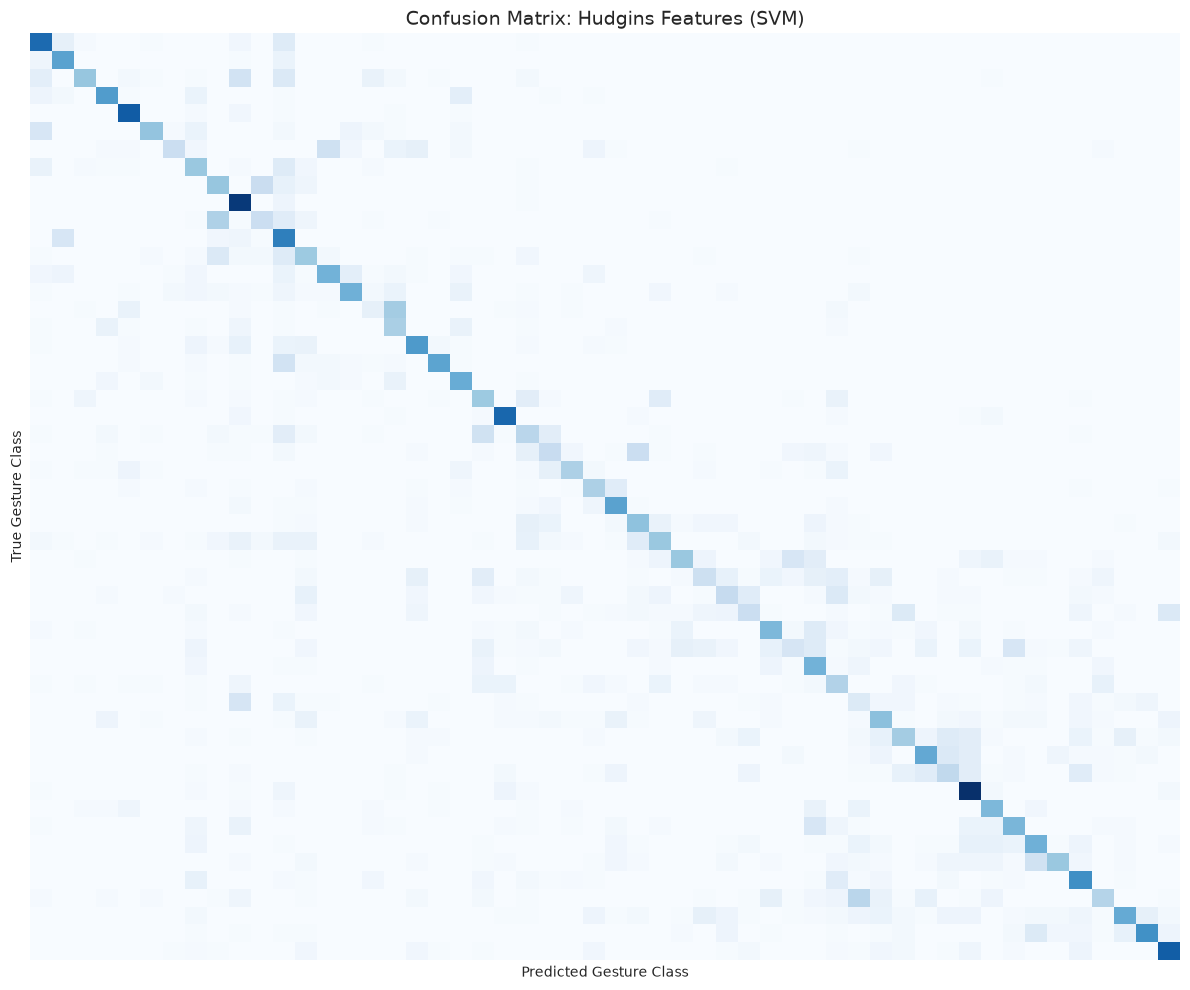

In [ ]:
# Determine the best model based on F1-Score
best_results = results_omp_1d if results_omp_1d['macro_f1'] > results_hudgins['macro_f1'] else results_hudgins
title_prefix = "OMP Features" if results_omp_1d['macro_f1'] > results_hudgins['macro_f1'] else "Hudgins Features"

plt.figure(figsize=(12, 10))
sns.heatmap(best_results['confusion_matrix'], cmap='Blues', cbar=False, 
            xticklabels=False, yticklabels=False)
plt.title(f"Confusion Matrix: {title_prefix} (SVM)", fontsize=14)
plt.xlabel("Predicted Gesture Class")
plt.ylabel("True Gesture Class")
plt.tight_layout()
plt.show()